# 07 Evaluation and Comparison

Bu notebook tüm modelleri aynı koşullarda karşılaştırmak için hazırlanmıştır.

Karşılaştırılan modeller:
- Popularity baseline
- Profile-based
- Content-based (TF-IDF)
- Content-based (SBERT)
- Collaborative filtering (TruncatedSVD)
- Collaborative filtering (LightFM)
- Hybrid (LightFM + multi-signal diverse rerank)

Kullanılan metrikler:
- Precision@10
- Hit Rate@10
- NDCG@10
- AUC
- Coverage
- User Coverage
- Diversity


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_INTERIM = PROJECT_ROOT / "data_interim"
OUTPUTS = PROJECT_ROOT / "outputs"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.advanced_models import build_sbert_embeddings, train_lightfm_model

products_clean = pd.read_csv(DATA_INTERIM / "products_clean.csv")
reviews_full = pd.read_csv(DATA_INTERIM / "reviews_full_features.csv")
product_profile = pd.read_csv(DATA_INTERIM / "product_profile.csv")

products_clean["product_id"] = products_clean["product_id"].astype(str)
reviews_full["author_id"] = reviews_full["author_id"].astype(str)
reviews_full["product_id"] = reviews_full["product_id"].astype(str)
reviews_full["submission_time"] = pd.to_datetime(reviews_full["submission_time"], errors="coerce")
product_profile["product_id"] = product_profile["product_id"].astype(str)

reviews_full = reviews_full.merge(
    products_clean[["product_id", "tertiary_category", "product_name", "brand_name"]],
    on="product_id",
    how="left",
)

profile_df = product_profile.merge(products_clean, on="product_id", how="left")

print("Products:", products_clean.shape)
print("Reviews full:", reviews_full.shape)


## Evaluation Split

Aynı kullanıcı için `rating >= 4` olan bir ürün test setine alınır, geri kalanı train setinde bırakılır.


In [2]:
user_interaction_counts = reviews_full.groupby("author_id")["product_id"].count()
eligible_users = user_interaction_counts[user_interaction_counts >= 5].index.tolist()

eval_df = reviews_full[reviews_full["author_id"].isin(eligible_users)].copy()
eval_df["is_relevant"] = (eval_df["rating"] >= 4).astype(int)

train_rows = []
test_rows = []
for user_id, group in eval_df.groupby("author_id"):
    relevant_rows = group[group["is_relevant"] == 1]
    if relevant_rows.empty:
        continue
    test_sample = relevant_rows.sample(n=1, random_state=42)
    train_sample = group.drop(test_sample.index)
    train_rows.append(train_sample)
    test_rows.append(test_sample)

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train users:", train_df["author_id"].nunique())
print("Test users:", test_df["author_id"].nunique())


Train shape: (329228, 13)
Test shape: (40173, 13)
Train users: 40173
Test users: 40173


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_73660/3320735564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_df, x="split", y="rows", palette="magma")


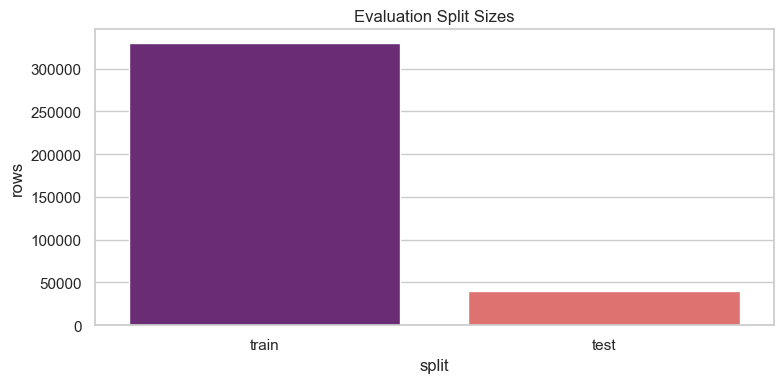

In [3]:
plt.figure(figsize=(8, 4))
split_df = pd.DataFrame({"split": ["train", "test"], "rows": [len(train_df), len(test_df)]})
sns.barplot(data=split_df, x="split", y="rows", palette="magma")
plt.title("Evaluation Split Sizes")
plt.tight_layout()


## Grafik Yorumu

Train-test ayrımı sonrasında test setinde her kullanıcı için bir adet ilgili ürün tutulmuştur. Bu yaklaşım, modelin kullanıcının geçmişine bakarak saklanan ürünü üst sıralarda getirip getiremediğini ölçmek için uygun bir ranking evaluation düzeni sunmaktadır.


## Shared Model Artifacts


In [ ]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(products_clean["product_text"].fillna(""))
similarity_matrix = cosine_similarity(tfidf_matrix)
productid_to_index = dict(zip(products_clean["product_id"], products_clean.index))
index_to_productid = dict(zip(products_clean.index, products_clean["product_id"]))

sbert_model_name = "all-MiniLM-L6-v2"
sbert_embeddings = build_sbert_embeddings(
    products_clean["product_text"].fillna(""),
    model_name=sbert_model_name,
    batch_size=64,
    show_progress_bar=True,
)

train_user_ids = train_df["author_id"].unique()
train_item_ids = train_df["product_id"].unique()
user_to_idx = {user_id: idx for idx, user_id in enumerate(train_user_ids)}
item_to_idx = {item_id: idx for idx, item_id in enumerate(train_item_ids)}

train_df["user_idx"] = train_df["author_id"].map(user_to_idx)
train_df["item_idx"] = train_df["product_id"].map(item_to_idx)
user_item_matrix = csr_matrix(
    (train_df["rating"], (train_df["user_idx"], train_df["item_idx"])),
    shape=(len(train_user_ids), len(train_item_ids))
)

svd = TruncatedSVD(n_components=50, random_state=42)
user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_.T
predicted_scores = user_factors @ item_factors.T

lightfm_artifacts = train_lightfm_model(
    interactions_df=train_df[["author_id", "product_id", "rating"]],
    user_ids=train_user_ids,
    item_ids=train_item_ids,
    positive_threshold=4.0,
    loss="warp",
    no_components=32,
    epochs=15,
    num_threads=4,
)

popularity_stats = (
    train_df.groupby("product_id")
    .agg(mean_rating=("rating", "mean"), review_count=("rating", "count"))
    .reset_index()
)

global_mean = train_df["rating"].mean()
m = 20
popularity_stats["popularity_score"] = (
    (popularity_stats["mean_rating"] * popularity_stats["review_count"] + global_mean * m)
    / (popularity_stats["review_count"] + m)
)
popularity_stats = popularity_stats.merge(
    products_clean[["product_id", "tertiary_category"]],
    on="product_id",
    how="left",
)

print("TF-IDF similarity matrix shape:", similarity_matrix.shape)
print("SBERT embedding shape:", sbert_embeddings.shape)
print("SVD score matrix shape:", predicted_scores.shape)
print("LightFM interaction shape:", lightfm_artifacts.interaction_shape)


## Helper Functions


In [ ]:
def min_max_normalize(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series([0] * len(series), index=series.index)
    return (series - min_val) / (max_val - min_val)


## Model Wrappers

Not: Her model test satırındaki kategoriye göre filtrelenir. Final karşılaştırmada temel LightFM modeli interaction-only kurulumla değerlendirilir. Hibrit satırı, önceki daha dengeli sonuçları veren dynamic CF-first rerank yaklaşımını temsil eder.


In [ ]:
from src.fast_eval import FastEvaluationModels

fast_models = FastEvaluationModels(
    train_df=train_df,
    products_clean=products_clean,
    profile_df=profile_df,
    popularity_stats=popularity_stats,
    predicted_scores=predicted_scores,
    train_item_ids=train_item_ids,
    user_to_idx=user_to_idx,
    similarity_matrix=similarity_matrix,
    productid_to_index=productid_to_index,
    index_to_productid=index_to_productid,
    sbert_embeddings=sbert_embeddings,
    lightfm_model_obj=lightfm_artifacts.model,
    lightfm_user_to_idx=lightfm_artifacts.user_to_idx,
    lightfm_item_ids=lightfm_artifacts.item_ids,
)

popularity_model = fast_models.popularity_model
profile_model = fast_models.profile_model
content_model = fast_models.content_model
sbert_content_model = fast_models.sbert_content_model
content_model_multi_seed = fast_models.content_model_multi_seed
cf_model = fast_models.cf_model
lightfm_cf_model = fast_models.lightfm_model
weighted_hybrid_model = fast_models.hybrid_model
legacy_hybrid_model = fast_models.hybrid_dynamic
hybrid_model = fast_models.hybrid_dynamic


## Metric Functions


In [7]:
category_product_map = (
    products_clean.assign(category_norm=products_clean["tertiary_category"].fillna("").astype(str).str.strip().str.lower())
    .groupby("category_norm")["product_id"]
    .apply(list)
    .to_dict()
)
train_seen_by_user = (
    train_df.groupby("author_id")["product_id"]
    .agg(lambda values: set(values.astype(str)))
    .to_dict()
)
total_catalog_items = products_clean["product_id"].nunique()


def build_model_evaluation_cache(
    model_func,
    test_data,
    top_k=10,
    auc_depth=100,
    negatives_per_positive=20,
    random_state=42,
):
    evaluation_cache = []
    rng = np.random.default_rng(random_state)
    request_depth = max(top_k, auc_depth)

    for _, row in test_data.iterrows():
        user_id = str(row["author_id"])
        true_product_id = str(row["product_id"])
        category = str(row["tertiary_category"]).strip().lower()

        candidate_pool = [
            product_id
            for product_id in category_product_map.get(category, [])
            if product_id != true_product_id and product_id not in train_seen_by_user.get(user_id, set())
        ]

        if not candidate_pool:
            continue

        negative_count = min(negatives_per_positive, len(candidate_pool))
        negative_items = rng.choice(candidate_pool, size=negative_count, replace=False).tolist()
        auc_candidate_ids = [true_product_id] + negative_items

        recs = model_func(row, top_n=request_depth)
        if recs is None or recs.empty:
            score_map = {}
            recommended_items = []
        else:
            score_col = [col for col in recs.columns if col != "product_id"][0]
            recommended_items = recs["product_id"].astype(str).tolist()
            score_map = pd.Series(recs[score_col].values, index=recs["product_id"].astype(str)).to_dict()

        auc_labels = [1] + [0] * negative_count
        auc_scores = [float(score_map.get(product_id, 0.0)) for product_id in auc_candidate_ids]

        evaluation_cache.append({
            "true_product_id": true_product_id,
            "recommended_items": recommended_items,
            "auc_labels": auc_labels,
            "auc_scores": auc_scores,
        })

    return evaluation_cache


def list_diversity(recommended_items, k=10):
    items = [str(item) for item in recommended_items[:k]]
    indices = [productid_to_index[item] for item in items if item in productid_to_index]

    if len(indices) < 2:
        return None

    sim_matrix = similarity_matrix[np.ix_(indices, indices)]
    upper_indices = np.triu_indices(len(indices), k=1)
    pairwise_similarities = sim_matrix[upper_indices]
    if len(pairwise_similarities) == 0:
        return None

    return float(np.mean(1 - pairwise_similarities))


def evaluate_prediction_cache(prediction_cache, total_requested, k=10):
    hits = 0
    total = 0
    ndcg_scores = []
    auc_scores = []
    diversity_scores = []
    recommended_catalog = set()

    for entry in prediction_cache:
        recommended_items = entry["recommended_items"][:k]
        true_item = entry["true_product_id"]

        recommended_catalog.update(recommended_items)

        if true_item in recommended_items:
            hits += 1

        dcg = 0.0
        for rank, item in enumerate(recommended_items, start=1):
            if item == true_item:
                dcg = 1 / np.log2(rank + 1)
                break
        ndcg_scores.append(dcg)

        labels = entry["auc_labels"]
        scores = entry["auc_scores"]
        if len(set(scores)) <= 1:
            auc_scores.append(0.5)
        else:
            auc_scores.append(roc_auc_score(labels, scores))

        diversity = list_diversity(recommended_items, k=k)
        if diversity is not None:
            diversity_scores.append(diversity)

        total += 1

    precision = hits / total if total else 0
    hit_rate = precision
    ndcg = float(np.mean(ndcg_scores)) if ndcg_scores else 0
    auc = float(np.mean(auc_scores)) if auc_scores else 0
    coverage = len(recommended_catalog) / total_catalog_items if total_catalog_items else 0
    user_coverage = total / total_requested if total_requested else 0
    diversity = float(np.mean(diversity_scores)) if diversity_scores else 0

    return {
        "precision@10": precision,
        "hit_rate@10": hit_rate,
        "ndcg@10": ndcg,
        "auc": auc,
        "coverage": coverage,
        "user_coverage": user_coverage,
        "diversity": diversity,
        "evaluated_rows": total,
    }



## Weighted Hybrid Baseline Tuning

Bu bölüm eski içerik+CF ağırlıklı baseline birleşimini hızlı bir referans olarak tutar. Final karşılaştırmada kullanılan hibrit model, önceki deneylerde daha dengeli sonuç veren dynamic CF-first rerank yaklaşımıdır.


In [8]:
sample_eval = test_df.head(200).copy()

hybrid_candidate_cache = []
for _, row in sample_eval.iterrows():
    content_rec = content_model(row, top_n=50)
    cf_rec = cf_model(row, top_n=50)

    if content_rec is None:
        content_rec = pd.DataFrame(columns=["product_id", "similarity_score"])
    if cf_rec is None:
        cf_rec = pd.DataFrame(columns=["product_id", "cf_score"])

    candidate_df = content_rec.merge(cf_rec, on="product_id", how="outer")
    if candidate_df.empty:
        continue

    candidate_df["similarity_score"] = candidate_df["similarity_score"].fillna(0)
    candidate_df["cf_score"] = candidate_df["cf_score"].fillna(0)
    candidate_df["content_norm"] = min_max_normalize(candidate_df["similarity_score"])
    candidate_df["cf_norm"] = min_max_normalize(candidate_df["cf_score"])

    hybrid_candidate_cache.append({
        "true_product_id": row["product_id"],
        "candidates": candidate_df[["product_id", "content_norm", "cf_norm"]].copy(),
    })


def precision_at_k_from_cache(candidate_cache, alpha, k=10):
    hits = 0
    total = 0

    for entry in candidate_cache:
        candidate_df = entry["candidates"].copy()
        candidate_df["final_score"] = (
            alpha * candidate_df["content_norm"]
            + (1 - alpha) * candidate_df["cf_norm"]
        )

        top_items = (
            candidate_df.sort_values("final_score", ascending=False)
            .head(k)["product_id"]
            .tolist()
        )

        if entry["true_product_id"] in top_items:
            hits += 1
        total += 1

    return hits / total if total else 0


alpha_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
alpha_results = []

for alpha in alpha_values:
    alpha_precision = precision_at_k_from_cache(hybrid_candidate_cache, alpha=alpha, k=10)
    alpha_results.append({"alpha": alpha, "precision@10": alpha_precision})

alpha_results_df = pd.DataFrame(alpha_results)
display(alpha_results_df)


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_73660/1373409396.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  candidate_df["similarity_score"] = candidate_df["similarity_score"].fillna(0)


,alpha,precision@10
0,0.1,0.615
1,0.2,0.615
2,0.3,0.600
3,0.4,0.560
4,0.5,0.550
5,0.6,0.425
6,0.7,0.340


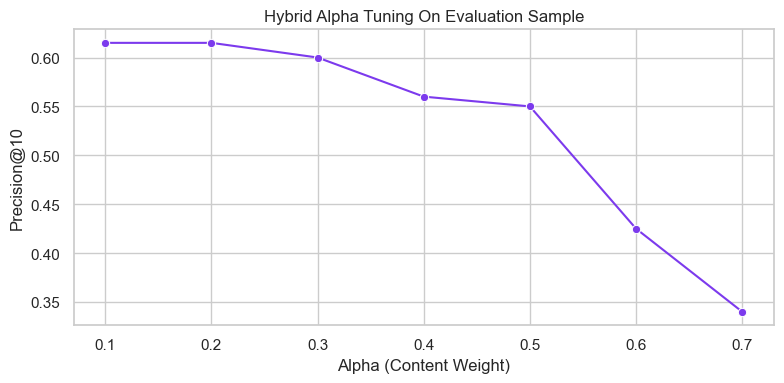

In [9]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=alpha_results_df, x="alpha", y="precision@10", marker="o", color="#7C3AED")
plt.title("Hybrid Alpha Tuning On Evaluation Sample")
plt.xlabel("Alpha (Content Weight)")
plt.ylabel("Precision@10")
plt.tight_layout()


## Grafik Yorumu

Bu bölüm sabit ağırlıklı hibrit temelinin davranışını görmek için tutulmaktadır. Ancak final comparison aşamasında kullanılan esas hibrit model, CF adaylarını multi-seed content sinyaliyle yeniden sıralayan dinamik bir birleşim stratejisidir.


## Final Comparison


In [ ]:
models = {
    "Popularity": popularity_model,
    "Profile-Based": profile_model,
    "Content-Based (TF-IDF)": content_model,
    "Content-Based (SBERT)": sbert_content_model,
    "Collaborative Filtering (SVD)": cf_model,
    "Collaborative Filtering (LightFM)": lightfm_cf_model,
    "Hybrid (Dynamic CF-first Rerank)": hybrid_model,
}

model_prediction_caches = {}
results = []

for model_name, model_func in models.items():
    prediction_cache = build_model_evaluation_cache(
        model_func,
        test_df,
        top_k=10,
        auc_depth=100,
        negatives_per_positive=20,
        random_state=42,
    )
    model_prediction_caches[model_name] = prediction_cache
    metrics = evaluate_prediction_cache(prediction_cache, total_requested=len(test_df), k=10)

    results.append({
        "model": model_name,
        "precision@10": metrics["precision@10"],
        "hit_rate@10": metrics["hit_rate@10"],
        "ndcg@10": metrics["ndcg@10"],
        "auc": metrics["auc"],
        "coverage": metrics["coverage"],
        "user_coverage": metrics["user_coverage"],
        "diversity": metrics["diversity"],
        "evaluated_rows": metrics["evaluated_rows"],
    })

results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv(OUTPUTS / "model_comparison_final.csv", index=False)


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

sns.barplot(data=results_df, x="model", y="precision@10", ax=axes[0], palette="crest")
axes[0].set_title("Precision@10 Comparison")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=results_df, x="model", y="hit_rate@10", ax=axes[1], palette="flare")
axes[1].set_title("Hit Rate@10 Comparison")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=results_df, x="model", y="ndcg@10", ax=axes[2], palette="mako")
axes[2].set_title("NDCG@10 Comparison")
axes[2].tick_params(axis="x", rotation=45)

sns.barplot(data=results_df, x="model", y="auc", ax=axes[3], palette="rocket")
axes[3].set_title("AUC Comparison")
axes[3].tick_params(axis="x", rotation=45)

sns.barplot(data=results_df, x="model", y="coverage", ax=axes[4], palette="viridis")
axes[4].set_title("Coverage Comparison")
axes[4].tick_params(axis="x", rotation=45)

sns.barplot(data=results_df, x="model", y="user_coverage", ax=axes[5], palette="cubehelix")
axes[5].set_title("User Coverage Comparison")
axes[5].tick_params(axis="x", rotation=45)

sns.barplot(data=results_df, x="model", y="diversity", ax=axes[6], palette="coolwarm")
axes[6].set_title("Diversity Comparison")
axes[6].tick_params(axis="x", rotation=45)

axes[7].axis("off")
plt.tight_layout()


## Final Sonuç Yorumu

Karşılaştırma grafikleri tüm modellerin aynı deney düzeni altındaki performansını özetlemektedir. Burada precision, NDCG ve AUC doğruluk ve sıralama kalitesini; coverage ve user coverage modelin ne kadar geniş bir ürün ve kullanıcı alanına hitap ettiğini; diversity ise öneri listesinin ne kadar çeşitli olduğunu göstermektedir. Final hibrit model LightFM aday havuzunu TF-IDF, SBERT, profile ve popularity sinyalleriyle birleştirir; son sıralamada birbirine fazla benzeyen ürünleri geriye iterek daha dengeli öneri listeleri üretmeyi hedefler.


## Interpretation Notes

Bu notebook sonunda tezde aşağıdaki sorular yanıtlanabilir:
- hangi model en yüksek sıralama kalitesini verdi?
- profile-based model hangi durumlarda faydalı oldu?
- hybrid model hangi sinyallerin birleşiminden güç aldı?
- kategori filtresi uygulandığında modellerin davranışı nasıl değişti?
